In [1]:
import torch
import numpy as np
import math
from utils.data_utils import *
from utils.viz_utils import *
# from model.motionPPGNet import motionPPGNet

from torch import nn
import torch.optim as optim
torch.manual_seed(42)
np.random.seed(42)

fs = 125
minBPM = 40
maxBPM = 240
window_length = 8 * fs
window_shift = 2 * fs  #Overlap = window_length - window_shift
batch_size = 25
verbose, epochs = 1, 100

# Retrieve dataset files
data_dir = "datasets/troika/training_data"
data_fls, ref_fls = LoadTroikaDataset(data_dir)

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cpu device


Window overlap: 750 samples (3 windows)
Train windows: 0 to 1379 (1380 windows)
Gap: 3 windows
Test windows: 1383 to 1725 (343 windows)


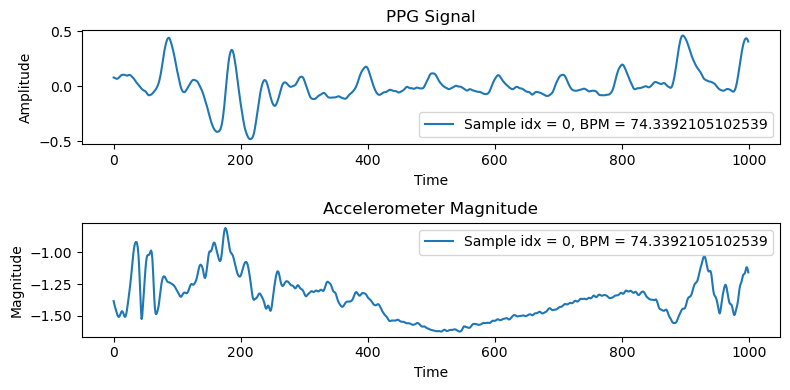

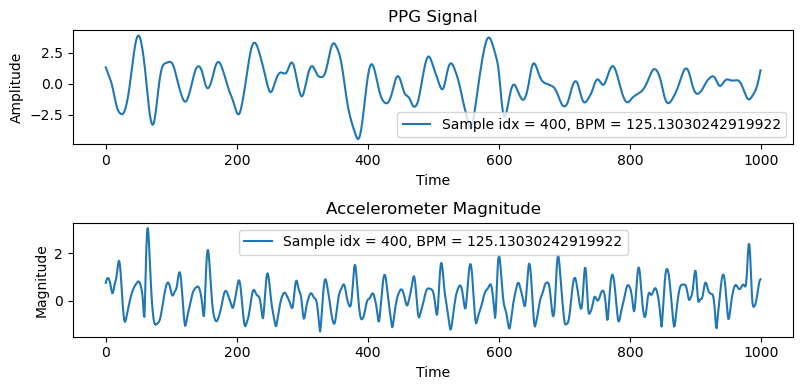

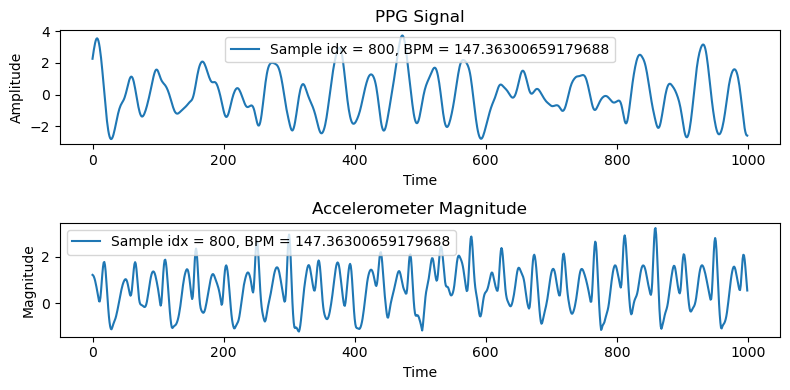

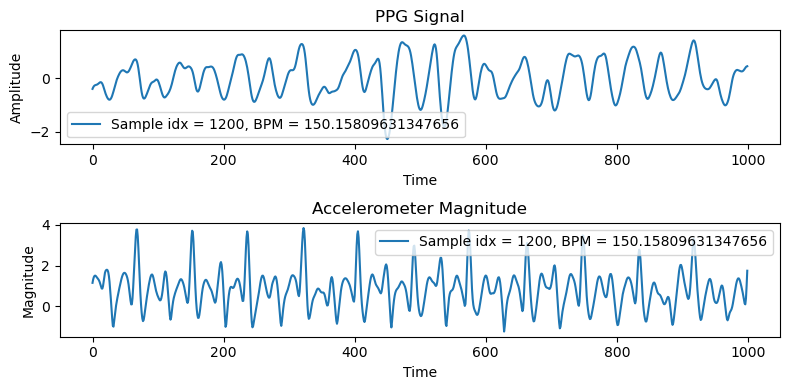

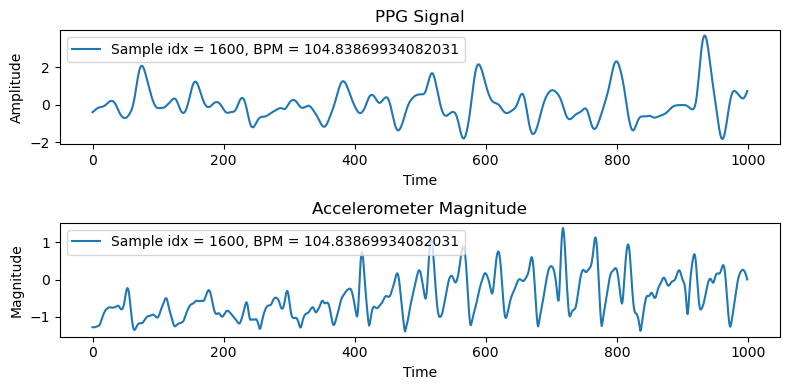

In [2]:
def create_overlap_aware_split(dataset, window_shift, window_length, train_ratio=0.8):
    """
    Create train/test split that accounts for window overlap.
    
    Args:
        dataset: Your TroikaDataset instance
        window_shift: Shift between consecutive windows (in samples)
        window_length: Length of each window (in samples)
        train_ratio: Desired proportion for training
    
    Returns:
        (train_loader, test_loader)
    """
    total_windows = len(dataset)
    
    # Calculate how many windows of overlap we have
    overlap_samples = window_length - window_shift
    overlap_windows = math.ceil(overlap_samples / window_shift)
    
    train_end = int(total_windows * train_ratio)
    
    # Create gap to prevent overlap
    test_start = train_end + overlap_windows
    
    if test_start >= total_windows:
        raise ValueError(f"Not enough data for split. Need at least {test_start} windows, but only have {total_windows}")
    
    train_indices = list(range(0, train_end))
    test_indices = list(range(test_start, total_windows))
    
    print(f"Window overlap: {overlap_samples} samples ({overlap_windows} windows)")
    print(f"Train windows: 0 to {train_end-1} ({len(train_indices)} windows)")
    print(f"Gap: {overlap_windows} windows")
    print(f"Test windows: {test_start} to {total_windows-1} ({len(test_indices)} windows)")
    
    # Create samplers
    train_sampler = torch.utils.data.SubsetRandomSampler(train_indices)
    test_sampler = torch.utils.data.SubsetRandomSampler(test_indices)
    
    # Create data loaders
    train_loader = DataLoader(dataset, batch_size=batch_size, sampler=train_sampler)
    test_loader = DataLoader(dataset, batch_size=batch_size, sampler=test_sampler)
    
    return train_loader, test_loader

# Create the dataset
dataset = TroikaDataset(data_fls, ref_fls, window_length, window_shift, fs)

# Split the dataset into training and testing
train_size = 0.8
num_train = int(len(dataset) * train_size)
num_test = len(dataset) - num_train
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [num_train, num_test])
train_loader, test_loader = create_overlap_aware_split(dataset, window_shift, window_length, train_ratio=0.8)

for i in range(0, len(dataset), 400):
    visualize_dataset_sample(dataset, i)
    

In [3]:
ppg, acc, targets = dataset[0]
print(ppg.shape)
print(acc.shape)
print(targets.shape)
print(targets)
for ppg, acc, targets in train_loader:
    print(ppg.shape)
    print(acc.shape)
    print(targets.shape)
    print(targets)
    break

torch.Size([1, 1000])
torch.Size([1, 1000])
torch.Size([])
tensor(74.3392)
torch.Size([25, 1, 1000])
torch.Size([25, 1, 1000])
torch.Size([25])
tensor([139.1753, 116.5372, 125.6545, 146.5798,  92.5926,  99.6933, 104.7260,
        145.7883, 157.3977, 135.2068, 163.3817, 115.8940, 152.2436,  81.4332,
        126.9841, 149.5278, 139.6070, 133.7793, 139.8026,  91.4630, 127.5239,
        113.6364,  80.7320, 134.6357, 138.1781])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class motionPPGNet(nn.Module):
    def __init__(self, n_timesteps, n_features, n_outputs):
        super(motionPPGNet, self).__init__()
        # Conv1D blocks
        self.conv1 = nn.Conv1d(in_channels=n_features, out_channels=32, kernel_size=40)
        self.bn1 = nn.BatchNorm1d(num_features=32)
        self.pool1 = nn.MaxPool1d(kernel_size=4)
        self.dropout1 = nn.Dropout(p=0.1)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=32, kernel_size=40)
        self.bn2 = nn.BatchNorm1d(num_features=32)
        self.pool2 = nn.MaxPool1d(kernel_size=4)
        self.dropout2 = nn.Dropout(p=0.1)
        
        # LSTM layers
        self.lstm1 = nn.LSTM(input_size=32, hidden_size=128, batch_first=True)
        self.lstm2 = nn.LSTM(input_size=128, hidden_size=128, batch_first=True)
        
        # Final dense layer for output
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.denseCNN = nn.Linear(in_features=32, out_features=n_outputs)
        self.denseCNNLSTM = nn.Linear(in_features=128, out_features=1)
        
        # Store activations
        self.activations = {}
        
    def forward(self, x):
        # x shape: (batch_size, n_features, n_timesteps)
        
        # Convolutional layers
        x = self.conv1(x)
        x = torch.relu(self.bn1(x))
        x = self.pool1(x)
        x = self.dropout1(x)
        
        x = self.conv2(x)
        x = torch.relu(self.bn2(x))
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # Reshape for LSTM: (batch_size, seq_len, features)
        x = x.permute(0, 2, 1)
        
        # LSTM layers
        x, (h1, c1) = self.lstm1(x)
        x, (h2, c2) = self.lstm2(x)
        
        # Use the final hidden state
        x = h2.squeeze(0)

        # Final dense layer
        x = self.denseCNNLSTM(x)

        # Uncomment with only CNN
        # x = self.global_avg_pool(x)  # (batch, 32, 1)
        # x = x.squeeze(-1)            # (batch, 32)
        # x = self.denseCNN(x)
        
        return x.squeeze(-1)  # Remove last dim if it's batch 1



n_timesteps, n_features, n_outputs = 1000, 1, 1

# Initialize the model
model = motionPPGNet(n_timesteps, n_features, n_outputs)
model.to(device)

# Loss and optimizer
criterion = nn.MSELoss()
learning_rate = 1e-3  # Reduce by 10x
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

/Users/tmagcaya/miniconda3/envs/torch/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

for epoch in range(1, epochs+1):
    model.train()
    epoch_train_loss = 0
    train_batches = 0
    for ppg, acc, targets in train_loader: 
        inputs, targets = ppg.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_train_loss += loss.item()
        train_batches += 1
    avg_train_loss = epoch_train_loss/train_batches

    if epoch % 10 == 0:  # Validation every 10 epochs
        model.eval()
        val_abs_error = 0
        val_batches = 0
        val_samples = 0
        with torch.no_grad():
            total_loss = 0
            for ppg, _, targets in test_loader:
                inputs, targets = ppg.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                abs_error = torch.abs(outputs - targets).sum().item()
                val_abs_error += abs_error
                val_batches +=1
                val_samples += targets.size(0)
                total_loss += loss.item()
            print(f'Epoch {epoch}:')
            print(f"Training Loss: {avg_train_loss:.2f}")
            print(f"Test&Val Loss: {total_loss / len(test_loader):.2f}")
            print(f"Val MAE: {val_abs_error / val_samples:.2f}")


Epoch 10:
Training Loss: 3757.95
Test&Val Loss: 5750.54
Val MAE: 72.83
  Train/Val Loss Ratio: 0.6535 (< 0.8 may indicate underfitting, > 1.2 may indicate overfitting)
Epoch 20:
Training Loss: 406.23
Test&Val Loss: 823.05
Val MAE: 25.52
  Train/Val Loss Ratio: 0.4936 (< 0.8 may indicate underfitting, > 1.2 may indicate overfitting)
Epoch 30:
Training Loss: 238.43
Test&Val Loss: 458.06
Val MAE: 18.98
  Train/Val Loss Ratio: 0.5205 (< 0.8 may indicate underfitting, > 1.2 may indicate overfitting)
Epoch 40:
Training Loss: 195.19
Test&Val Loss: 395.12
Val MAE: 17.07
  Train/Val Loss Ratio: 0.4940 (< 0.8 may indicate underfitting, > 1.2 may indicate overfitting)
Epoch 50:
Training Loss: 119.36
Test&Val Loss: 718.92
Val MAE: 22.52
  Train/Val Loss Ratio: 0.1660 (< 0.8 may indicate underfitting, > 1.2 may indicate overfitting)
Epoch 60:
Training Loss: 92.84
Test&Val Loss: 153.95
Val MAE: 10.54
  Train/Val Loss Ratio: 0.6030 (< 0.8 may indicate underfitting, > 1.2 may indicate overfitting)
Epo

In [6]:
"""Print a simple text representation of PyTorch model structure"""
print("=" * 60)
print("PYTORCH MODEL STRUCTURE")
print("=" * 60)
print(model)

# Print parameter count
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")
print("=" * 60)

PYTORCH MODEL STRUCTURE
motionPPGNet(
  (conv1): Conv1d(1, 32, kernel_size=(40,), stride=(1,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.1, inplace=False)
  (conv2): Conv1d(32, 32, kernel_size=(40,), stride=(1,))
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.1, inplace=False)
  (lstm1): LSTM(32, 128, batch_first=True)
  (lstm2): LSTM(128, 128, batch_first=True)
  (global_avg_pool): AdaptiveAvgPool1d(output_size=1)
  (denseCNN): Linear(in_features=32, out_features=1, bias=True)
  (denseCNNLSTM): Linear(in_features=128, out_features=1, bias=True)
)

Total trainable parameters: 257,634
